# SDG Goal 3 Variables vs CALE

This notebook runs one OLS regression per SDG Goal 3 variable from `sdg_year.csv`.

Model:

`CALE ~ SDG3 variable + log(total population) + age65 share + continent fixed effects`

It saves a compact CSV summary and plots fitted lines for significant variables (p < 0.05). No LaTeX tables or Bayesian models are produced.

In [186]:
# (1) Imports and paths
import os
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import textwrap

PROJECT_ROOT = Path("..")
SDG_YEAR_PATH = PROJECT_ROOT / "data" / "sdg" / "api_iso36_all" / "sdg_year.csv"
FEATURE_CROSSWALK_PATH = PROJECT_ROOT / "data" / "sdg" / "api_iso36_all" / "sdg_year_feature_crosswalk.csv"
ISO_PATH = PROJECT_ROOT / "data" / "iso36.csv"
METRICS_PATH = PROJECT_ROOT / "results" / "f2_gompertz" / "table" / "gompertz_derived_metrics_by_country.csv"
WB_PATH = PROJECT_ROOT / "data" / "wb" / "wb_last_survey_year.csv"
OUT_DIR = PROJECT_ROOT / "results" / "f5_reg3var"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_SUMMARY = OUT_DIR / "sdg_goal3_ols_summary.csv"
OUT_DATA = OUT_DIR / "sdg_goal3_regression_dataset.csv"

print("SDG_YEAR_PATH:", SDG_YEAR_PATH)
print("FEATURE_CROSSWALK_PATH:", FEATURE_CROSSWALK_PATH)
print("METRICS_PATH:", METRICS_PATH)
print("WB_PATH:", WB_PATH)
print("OUT_DIR:", OUT_DIR)

SDG_YEAR_PATH: ../data/sdg/api_iso36_all/sdg_year.csv
FEATURE_CROSSWALK_PATH: ../data/sdg/api_iso36_all/sdg_year_feature_crosswalk.csv
METRICS_PATH: ../results/f2_gompertz/table/gompertz_derived_metrics_by_country.csv
WB_PATH: ../data/wb/wb_last_survey_year.csv
OUT_DIR: ../results/f5_reg3var


In [187]:
# (2) Load and merge data
sdg = pd.read_csv(SDG_YEAR_PATH)
iso = pd.read_csv(ISO_PATH)
metrics = pd.read_csv(METRICS_PATH)
wb = pd.read_csv(WB_PATH)
features = pd.read_csv(FEATURE_CROSSWALK_PATH)

iso = iso.rename(columns={"isocountry_c": "country"})
iso["country"] = iso["country"].astype(str).str.strip()
iso["iso3c"] = iso["iso3c"].astype(str).str.strip().str.upper()

sdg["iso3c"] = sdg["iso3c"].astype(str).str.strip().str.upper()
sdg["country"] = sdg["country"].astype(str).str.strip()

metrics = metrics.rename(columns={"rmst": "CALE"})
metrics["country"] = metrics["country"].astype(str).str.strip()

wb = wb.copy()
wb["iso3c"] = wb["iso3c"].astype(str).str.strip().str.upper()
wb["year"] = pd.to_numeric(wb["year"], errors="coerce")
wb["log_total_population"] = np.log(pd.to_numeric(wb["total_population"], errors="coerce"))

merged = (
    sdg.merge(iso[["country", "iso3c"]], on=["country", "iso3c"], how="left", suffixes=("", "_iso"))
    .merge(metrics[["country", "CALE", "n", "events"]], on="country", how="left")
    .merge(wb[["iso3c", "year", "total_population", "log_total_population", "age65_share"]], on="iso3c", how="left")
    .rename(columns={"year": "wb_year"})
)
missing_cale = merged.loc[merged["CALE"].isna(), "country"].tolist()
if missing_cale:
    print("Countries still missing CALE:", missing_cale)

# Coarse continent labels, kept local to avoid relying on other files.
continent_map = {
    "AUS": "Oceania",
    "CHN": "Asia", "IND": "Asia", "ISR": "Asia", "JPN": "Asia", "KOR": "Asia",
    "MEX": "North America", "USA": "North America",
}
merged["continent"] = merged["iso3c"].map(continent_map).fillna("Europe")

sdg_vars = [c for c in merged.columns if c.startswith("sdg3_")]
for col in sdg_vars + ["CALE", "log_total_population", "age65_share"]:
    if col in merged.columns:
        merged[col] = pd.to_numeric(merged[col], errors="coerce")

merged.to_csv(OUT_DATA, index=False)

print("Merged shape:", merged.shape)
print("SDG variables:", len(sdg_vars))
print("Saved:", OUT_DATA)
merged[["country", "iso3c", "CALE", "log_total_population", "age65_share", "continent"]].head()

Merged shape: (36, 661)
SDG variables: 41
Saved: ../results/f5_reg3var/sdg_goal3_regression_dataset.csv


,country,iso3c,CALE,log_total_population,age65_share,continent
0,Australia,AUS,78.245676,16.971476,14.634393,Oceania
1,Austria,AUT,82.418923,16.017374,19.789751,Europe
2,Belgium,BEL,81.057009,16.273407,19.767193,Europe
3,Bulgaria,BGR,77.569946,15.681929,21.697297,Europe
4,China,CHN,76.793885,21.061708,11.516209,Asia


In [188]:
# (3) Standardization helper
def zscore(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.nan, index=s.index)
    return (s - s.mean()) / sd

reg_df = merged.copy()
standardize_cols = ["CALE", "log_total_population", "age65_share"] + sdg_vars
for col in standardize_cols:
    if col in reg_df.columns:
        reg_df[col] = zscore(reg_df[col])

base_control_cols = ["log_total_population", "age65_share"]
print("Regression rows before per-variable NA filtering:", len(reg_df))
print("Controls:", base_control_cols)

Regression rows before per-variable NA filtering: 36
Controls: ['log_total_population', 'age65_share']


In [189]:
# (4) Keep only SDG variables with at most 3 missing values
MAX_MISSING_PER_SDG_VAR = 3
sdg_vars_all = list(sdg_vars)

sdg_missing = (
    reg_df[sdg_vars_all]
    .isna()
    .sum()
    .rename("missing_n")
    .reset_index()
    .rename(columns={"index": "variable"})
)
sdg_missing["missing_share"] = sdg_missing["missing_n"] / len(reg_df)
sdg_missing = sdg_missing.sort_values(["missing_n", "variable"]).reset_index(drop=True)

sdg_vars = sdg_missing.loc[sdg_missing["missing_n"] <= MAX_MISSING_PER_SDG_VAR, "variable"].tolist()
dropped_sdg_vars = sdg_missing.loc[sdg_missing["missing_n"] > MAX_MISSING_PER_SDG_VAR, "variable"].tolist()

# Keep the exported regression dataset aligned with variables that actually enter the regression loop.
non_sdg_cols = [c for c in merged.columns if not c.startswith("sdg")]
merged_filtered = merged[non_sdg_cols + sdg_vars].copy()
merged_filtered.to_csv(OUT_DATA, index=False)

print(f"Total SDG variables before missingness filter: {len(sdg_vars_all)}")
print(f"SDG variables with missing_n <= {MAX_MISSING_PER_SDG_VAR}: {len(sdg_vars)}")
print(f"SDG variables dropped for missing_n > {MAX_MISSING_PER_SDG_VAR}: {len(dropped_sdg_vars)}")
print("Missingness distribution:")
print(sdg_missing["missing_n"].value_counts().sort_index().to_string())
print("Saved filtered regression dataset:", OUT_DATA)
sdg_missing.head(20)

# Export missingness/inclusion table for SDG3 variables.
MISSINGNESS_TEX_PATH = OUT_DIR / "sdg_goal3_missingness_inclusion.tex"


def target_from_indicator(indicator):
    parts = str(indicator).split(".")
    return ".".join(parts[:-1]) if len(parts) > 1 else str(indicator)


def sdg_code_sort_key(value):
    out = []
    for part in str(value).split("."):
        if part.isdigit():
            out.append(int(part))
        elif part.isalpha():
            out.append(100 + ord(part.lower()[0]) - ord("a"))
        else:
            out.append(999)
    return tuple(out)


def latex_escape_cell(value):
    text = "" if pd.isna(value) else str(value)
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    return "".join(replacements.get(ch, ch) for ch in text)


missing_table = sdg_missing.merge(
    features[["feature_id", "indicator", "seriesDescription"]],
    left_on="variable",
    right_on="feature_id",
    how="left",
).drop(columns=["feature_id"])
missing_table["Target"] = missing_table["indicator"].map(target_from_indicator)
missing_table["Indicator"] = missing_table["indicator"].astype(str) + " " + missing_table["seriesDescription"].fillna("").astype(str)
missing_table["n"] = len(reg_df) - missing_table["missing_n"]
missing_table["Inclusion"] = np.where(missing_table["missing_n"] <= MAX_MISSING_PER_SDG_VAR, r"$\checkmark$", "")
missing_table["target_sort"] = missing_table["Target"].map(sdg_code_sort_key)
missing_table["indicator_sort"] = missing_table["indicator"].map(sdg_code_sort_key)
missing_table = missing_table.sort_values(["target_sort", "indicator_sort", "seriesDescription", "variable"]).reset_index(drop=True)

latex_lines = [
    r"\begin{longtable}{llccc}",
    r"\caption{SDG Goal 3 indicator missingness and inclusion}\\",
    r"\hline\hline",
    r"Target & Indicator & n & missing n & Inclusion \\",
    r"\hline",
    r"\endhead",
    r"\hline\hline",
    r"\endfoot",
]
for _, row in missing_table.iterrows():
    latex_lines.append(
        " & ".join([
            latex_escape_cell(row["Target"]),
            latex_escape_cell(row["Indicator"]),
            str(int(row["n"])),
            str(int(row["missing_n"])),
            row["Inclusion"],
        ]) + r" \\"
    )
latex_lines.append(r"\end{longtable}")
latex_lines.append("")
MISSINGNESS_TEX_PATH.write_text("\n".join(latex_lines))
print("Saved missingness/inclusion table:", MISSINGNESS_TEX_PATH)
display(missing_table[["Target", "Indicator", "n", "missing_n", "Inclusion"]])


Total SDG variables before missingness filter: 41
SDG variables with missing_n <= 3: 29
SDG variables dropped for missing_n > 3: 12
Missingness distribution:
missing_n
0     27
1      1
3      1
4      2
5      2
11     3
25     1
32     3
36     1
Saved filtered regression dataset: ../results/f5_reg3var/sdg_goal3_regression_dataset.csv
Saved missingness/inclusion table: ../results/f5_reg3var/sdg_goal3_missingness_inclusion.tex


,Target,Indicator,n,missing_n,Inclusion
0,3.1,3.1.1 Maternal mortality ratio,36,0,$\checkmark$
1,3.1,3.1.2 Proportion of births attended by skilled...,31,5,
2,3.2,3.2.1 Infant deaths (number),36,0,$\checkmark$
3,3.2,"3.2.1 Infant mortality rate (deaths per 1,000 ...",36,0,$\checkmark$
4,3.2,3.2.1 Under-five deaths (number),36,0,$\checkmark$
5,3.2,"3.2.1 Under-five mortality rate, by sex (death...",36,0,$\checkmark$
6,3.2,3.2.2 Neonatal deaths (number),36,0,$\checkmark$
7,3.2,"3.2.2 Neonatal mortality rate (deaths per 1,00...",36,0,$\checkmark$
8,3.3,"3.3.1 Number of new HIV infections per 1,000 u...",25,11,
9,3.3,"3.3.2 Tuberculosis incidence (per 100,000 popu...",36,0,$\checkmark$


In [5]:
# (5) Run one OLS regression per SDG variable
def fit_one_sdg_var(var: str):
    use_cols = ["CALE", "continent"] + base_control_cols + [var]
    sub = reg_df[use_cols].dropna().copy()
    if sub.shape[0] < 8:
        return None, sub
    if sub[var].nunique(dropna=True) < 2:
        return None, sub

    X = sub[base_control_cols + [var]].copy()
    fe = pd.get_dummies(sub["continent"], prefix="continent", drop_first=True, dtype=float)
    X = pd.concat([X, fe], axis=1)
    X = sm.add_constant(X, has_constant="add")
    y = sub["CALE"]

    model = sm.OLS(y, X).fit(cov_type="HC3")
    return model, sub

results = []
models = {}
for var in sdg_vars:
    model, sub = fit_one_sdg_var(var)
    if model is None:
        results.append({
            "variable": var,
            "n": len(sub),
            "status": "skipped_insufficient_data",
            "coef": np.nan,
            "se": np.nan,
            "pvalue": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "r2": np.nan,
            "adj_r2": np.nan,
        })
        continue

    ci = model.conf_int().loc[var]
    results.append({
        "variable": var,
        "n": int(model.nobs),
        "status": "fit",
        "coef": model.params[var],
        "se": model.bse[var],
        "pvalue": model.pvalues[var],
        "ci_low": ci.iloc[0],
        "ci_high": ci.iloc[1],
        "r2": model.rsquared,
        "adj_r2": model.rsquared_adj,
    })
    models[var] = model

summary = pd.DataFrame(results)
summary = summary.merge(
    features[["feature_id", "goal", "indicator", "series", "seriesDescription", "attr_Units"]],
    left_on="variable",
    right_on="feature_id",
    how="left",
).drop(columns=["feature_id"])
front_cols = ["variable", "goal", "indicator", "series", "seriesDescription", "attr_Units"]
other_cols = [c for c in summary.columns if c not in front_cols]
summary = summary[front_cols + other_cols].sort_values(["pvalue", "variable"], na_position="last")
summary.to_csv(OUT_SUMMARY, index=False)

print("Fitted models:", len(models))
print("Skipped:", (summary["status"] != "fit").sum())
print("Saved:", OUT_SUMMARY)
summary[["indicator", "seriesDescription", "n", "pvalue"]].head(50)

Fitted models: 29
Skipped: 0
Saved: ../results/f5_reg3var/sdg_goal3_ols_summary.csv


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2


,indicator,seriesDescription,n,pvalue
19,3.9.1,Age-standardized mortality rate attributed to ...,36,0.001066
17,3.8.1,Universal health coverage (UHC) service covera...,36,0.004692
18,3.9.1,Age-standardized mortality rate attributed to ...,36,0.005050
27,3.9.1,Age-standardized mortality rate attributed to ...,35,0.010230
10,3.4.1,Mortality rate attributed to cardiovascular di...,36,0.020048
26,3.d.1,International Health Regulations (IHR) capacit...,36,0.037675
7,3.3.2,"Tuberculosis incidence (per 100,000 population)",36,0.039981
0,3.1.1,Maternal mortality ratio,36,0.053113
14,3.6.1,"Death rate due to road traffic injuries, by se...",36,0.075501
16,3.7.2,"Adolescent birth rate (per 1,000 women aged 15...",36,0.077760


Significant SDG3 variables at p < 0.05: 7


,indicator,seriesDescription,n,pvalue
0,3.3.2,"Tuberculosis incidence (per 100,000 population)",36,0.039981
1,3.4.1,Mortality rate attributed to cardiovascular di...,36,0.020048
2,3.8.1,Universal health coverage (UHC) service covera...,36,0.004692
3,3.9.1,Age-standardized mortality rate attributed to ...,36,0.005050
4,3.9.1,Age-standardized mortality rate attributed to ...,35,0.010230
5,3.9.1,Age-standardized mortality rate attributed to ...,36,0.001066
6,3.d.1,International Health Regulations (IHR) capacit...,36,0.037675


First-row plot order: blank, then
3.3.2 sdg3_3_3_2_SH_TBS_INCD
3.4.1 sdg3_3_4_1_SH_DTH_NCOM
3.8.1 sdg3_3_8_1_SH_ACS_UNHC_25
Second-row plot order:
3.9.1 sdg3_3_9_1_SH_AAP_ASMORT
3.9.1 sdg3_3_9_1_SH_HAP_ASMORT
3.9.1 sdg3_3_9_1_SH_STA_ASAIRP
3.d.1 sdg3_3_d_1_SH_IHR_CAPS


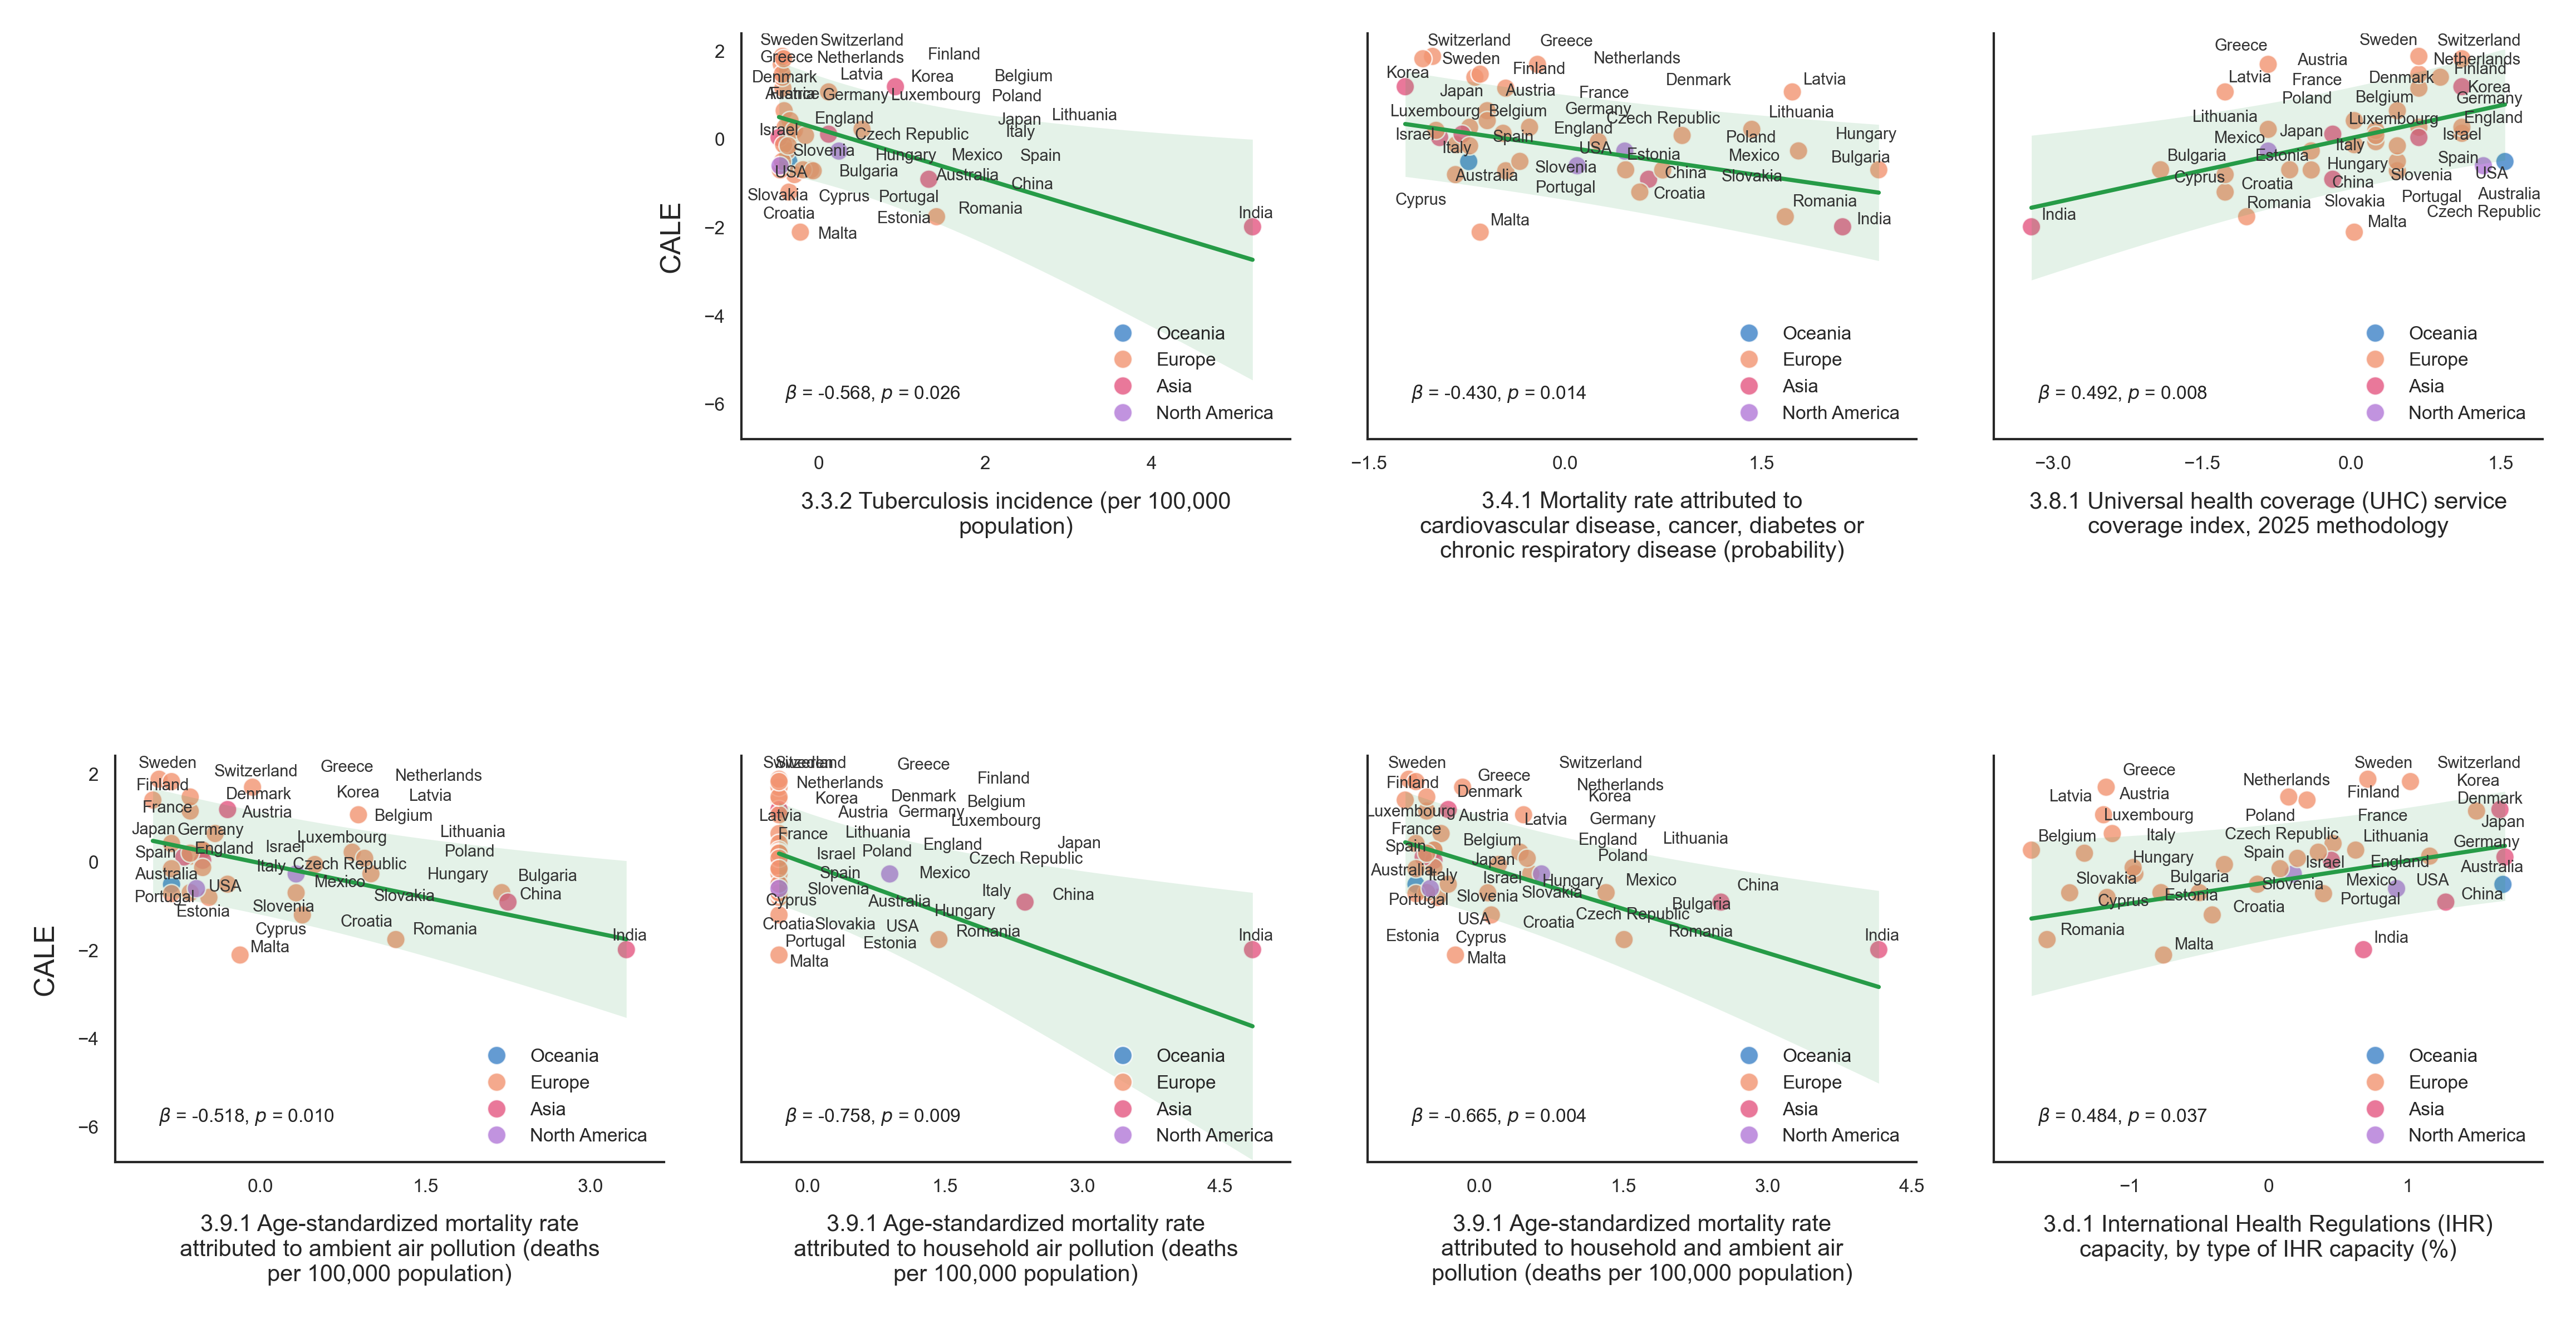

Saved: ../results/f5_reg3var/significant_fits_goal3.pdf


In [6]:

# (6) Plot fitted lines for significant SDG3 variables (p < 0.05)
sns.set_theme(style="white")

sig = summary.loc[(summary["status"] == "fit") & (summary["pvalue"] < 0.05)].copy()
sig["indicator_sort"] = sig["indicator"].astype(str).str.extract(r"3\.(\d+)")[0].astype(float)
sig = sig.sort_values(["indicator_sort", "indicator", "series"]).reset_index(drop=True)
print("Significant SDG3 variables at p < 0.05:", len(sig))
display_cols = ["variable", "goal", "indicator", "series", "seriesDescription", "n", "coef", "se", "pvalue", "ci_low", "ci_high", "r2"]
display(sig[["indicator", "seriesDescription", "n", "pvalue"]].head(50))

first_row_vars = sig.loc[sig["indicator"].astype(str).isin(["3.3.2", "3.4.1", "3.8.1"]), "variable"].tolist()
vars_391 = sig.loc[sig["indicator"].astype(str).eq("3.9.1"), "variable"].tolist()
var_3d1 = sig.loc[sig["indicator"].astype(str).eq("3.d.1"), "variable"].tolist()
sig_vars = first_row_vars + vars_391 + var_3d1

if not sig_vars:
    print("No SDG3 variables with p < 0.05 to plot.")
else:
    continent_palette = {
        "Europe": "#F29471",
        "Asia": "#E45781",
        "North America": "#B279D8",
        "Oceania": "#3E83C7",
    }

    try:
        from adjustText import adjust_text
    except Exception:
        adjust_text = None

    label_df = summary.set_index("variable")
    desc_map = label_df["seriesDescription"].fillna(label_df["series"]).to_dict()
    indicator_map = label_df["indicator"].astype(str).to_dict()

    def short_label(text, width=45):
        text = str(text)
        return "\n".join(textwrap.wrap(text, width=width)) if len(text) > width else text

    def x_label_for(var):
        indicator = indicator_map.get(var, "")
        desc = desc_map.get(var, var)
        return short_label(f"{indicator} {desc}")

    def plot_grid(vars_plot: list, out_name: str) -> None:
        nrows, ncols = 3, 4
        fig_width = 200 / 25.4  # 200 mm in inches
        fig_height = 150 / 25.4
        fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height), dpi=600, sharey=False)
        fig.patch.set_facecolor("none")
        fig.patch.set_alpha(0.0)
        axes_flat = axes.ravel()
        y_ticks = [-6, -4, -2, 0, 2]
        y_limits = (-6.8, 2.4)

        panel_vars = [None] + first_row_vars + vars_391 + var_3d1
        for ax_idx, ax in enumerate(axes_flat):
            if ax_idx >= len(panel_vars) or panel_vars[ax_idx] is None:
                ax.set_visible(False)
                continue

            var = panel_vars[ax_idx]
            ax.set_facecolor("none")
            ax.set_ylim(*y_limits)
            use_cols = ["CALE", "country", "continent"] + base_control_cols + [var]
            sub = reg_df[use_cols].replace([np.inf, -np.inf], np.nan).dropna(subset=use_cols).copy()
            if sub.empty:
                ax.set_visible(False)
                continue

            X_df = sub[base_control_cols + [var]].copy()
            continent_dummies = pd.get_dummies(sub["continent"], prefix="continent", drop_first=True, dtype=float)
            X_df = pd.concat([X_df, continent_dummies], axis=1)
            X_df = X_df.apply(pd.to_numeric, errors="coerce").astype(float)
            X1 = sm.add_constant(X_df, has_constant="add")
            y = sub["CALE"].to_numpy(dtype=float)
            fit = sm.OLS(y, X1).fit()

            x_vals = np.linspace(sub[var].min(), sub[var].max(), 200)
            mean_controls = sub[base_control_cols].mean()
            pred_df = pd.DataFrame({var: x_vals})
            for c in base_control_cols:
                pred_df[c] = mean_controls[c]
            for col in continent_dummies.columns:
                pred_df[col] = 0.0
            pred_X1 = sm.add_constant(pred_df[X_df.columns], has_constant="add")
            pred_frame = fit.get_prediction(pred_X1).summary_frame(alpha=0.05)
            y_hat = pred_frame["mean"].to_numpy()
            y_lower = pred_frame["mean_ci_lower"].to_numpy()
            y_upper = pred_frame["mean_ci_upper"].to_numpy()

            sns.scatterplot(
                data=sub,
                x=var,
                y="CALE",
                hue="continent",
                palette=continent_palette,
                s=16,
                alpha=0.8,
                ax=ax,
                legend=True,
            )
            texts = []
            x_text_offset = 0.012 * (sub[var].max() - sub[var].min())
            y_text_offset = 0.012 * (y_limits[1] - y_limits[0])
            for xi, yi, name in zip(sub[var].to_numpy(), sub["CALE"].to_numpy(), sub["country"].astype(str)):
                if pd.isna(xi) or pd.isna(yi):
                    continue
                texts.append(ax.text(xi + x_text_offset, yi + y_text_offset, name, fontsize=3.5, color="#333333", clip_on=True))
            if adjust_text is not None and texts:
                adjust_text(texts, ax=ax, only_move={"points": "y", "text": "xy"}, force_text=0.2)

            ax.legend(frameon=False, loc="lower right", fontsize=4, title_fontsize=5)
            line_color = "#269B47"
            ax.plot(x_vals, y_hat, color=line_color, linewidth=0.9)
            ax.fill_between(x_vals, y_lower, y_upper, color=line_color, alpha=0.12, linewidth=0)

            beta_val = float(fit.params[var])
            p_val = float(fit.pvalues[var])
            ax.text(
                0.08,
                0.1,
                rf"$\it{{\beta}}$ = {beta_val:.3f}, $\it{{p}}$ = {p_val:.3f}",
                transform=ax.transAxes,
                fontsize=4,
                color="#222222",
            )

            ax.set_xlabel(x_label_for(var), fontsize=5)
            show_y_axis = (indicator_map.get(var) == "3.3.2") or (var == "sdg3_3_9_1_SH_AAP_ASMORT")
            ax.set_yticks(y_ticks)
            ax.tick_params(axis="both", labelsize=4, length=0)
            ax.set_ylabel("CALE" if show_y_axis else "", fontsize=6)
            ax.tick_params(axis="y", which="both", labelleft=show_y_axis, left=False, length=0)
            if show_y_axis:
                ax.yaxis.set_tick_params(labelleft=True)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_linewidth(0.5)
            ax.spines["bottom"].set_linewidth(0.5)
            ax.grid(False)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
            ax.margins(x=0.08, y=0.08)

        fig.tight_layout()
        fig.subplots_adjust(hspace=0.78, wspace=0.14)
        out_path = OUT_DIR / out_name
        plt.savefig(out_path, dpi=600, transparent=True, facecolor="none", edgecolor="none", bbox_inches="tight", pad_inches=0.02)
        plt.show()
        print("Saved:", out_path)

    print("First-row plot order: blank, then")
    for var in first_row_vars:
        print(indicator_map.get(var), var)
    print("Second-row plot order:")
    for var in vars_391 + var_3d1:
        print(indicator_map.get(var), var)
    plot_grid(sig_vars, "significant_fits_goal3.pdf")


## LaTeX significant-model table

In [7]:
# (7) Export significant SDG3 models as a LaTeX table
LATEX_TABLE_PATH = OUT_DIR / "sdg_goal3_ols_summary_longtable.tex"


def indicator_sort_key(value):
    parts = str(value).replace(".d", ".999").replace(".a", ".997").replace(".b", ".998").split(".")
    out = []
    for p in parts:
        try:
            out.append(int(p))
        except Exception:
            out.append(9999)
    return tuple(out)


def latex_escape(value):
    text = "" if pd.isna(value) else str(value)
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    return "".join(replacements.get(ch, ch) for ch in text)


def fmt_num(value, digits=3):
    if pd.isna(value) or not np.isfinite(value):
        return ""
    return f"{float(value):.{digits}f}"


def fmt_p(value):
    if pd.isna(value) or not np.isfinite(value):
        return ""
    return f"{float(value):.3f}"


def coef_p_cell(model, param):
    if param not in model.params.index:
        return ""
    coef = fmt_num(model.params[param])
    pval = fmt_p(model.pvalues[param])
    return rf"\begin{{tabular}}[c]{{@{{}}c@{{}}}}{coef}\\({pval})\end{{tabular}}"


def fit_one_model_for_table(var):
    use_cols = ["CALE", "continent"] + base_control_cols + [var]
    sub = reg_df[use_cols].dropna().copy()
    X = sub[base_control_cols + [var]].apply(pd.to_numeric, errors="coerce").astype(float)
    fe = pd.get_dummies(sub["continent"], prefix="continent", drop_first=True, dtype=float)
    X = pd.concat([X, fe], axis=1)
    X = sm.add_constant(X, has_constant="add")
    y = pd.to_numeric(sub["CALE"], errors="coerce").astype(float)
    model = sm.OLS(y, X).fit(cov_type="HC3")
    return model


if "summary" not in globals() or summary.empty:
    raise RuntimeError("Run cell (5) first to create summary before exporting the LaTeX table.")

sig_table = summary.loc[(summary["status"] == "fit") & (summary["pvalue"] < 0.05)].copy()
if sig_table.empty:
    LATEX_TABLE_PATH.write_text("% No SDG3 variables with p < 0.05.\n")
    print("No SDG3 variables with p < 0.05.")
else:
    sig_table["indicator_sort"] = sig_table["indicator"].map(indicator_sort_key)
    sig_table = sig_table.sort_values(["indicator_sort", "seriesDescription", "series", "variable"]).reset_index(drop=True)
    model_vars = sig_table["variable"].tolist()
    table_models = {var: fit_one_model_for_table(var) for var in model_vars}

    model_headers = [f"Model {i}" for i in range(1, len(model_vars) + 1)]
    colspec = "l" + "c" * len(model_vars)

    rows = []

    # One row per significant SDG variable. Each variable appears only in its own model column.
    for row_idx, row in sig_table.iterrows():
        var = row["variable"]
        label = latex_escape(row["seriesDescription"])
        cells = [""] * len(model_vars)
        cells[row_idx] = coef_p_cell(table_models[var], var)
        rows.append([label] + cells)

    control_rows = [
        ("log_total_population", "Log total population"),
        ("age65_share", r"Population aged $\geq 65$"),
    ]
    fe_params = sorted(
        {
            param
            for model in table_models.values()
            for param in model.params.index
            if param.startswith("continent_")
        }
    )
    fe_rows = [
        (param, "Continent: " + latex_escape(param.replace("continent_", "").replace("_", " ")))
        for param in fe_params
    ]

    for param, label in control_rows + fe_rows:
        rows.append([label] + [coef_p_cell(table_models[var], param) for var in model_vars])

    obs_row = ["Observations"] + [str(int(table_models[var].nobs)) for var in model_vars]
    r2_row = [r"$R^2$"] + [fmt_num(table_models[var].rsquared) for var in model_vars]
    aic_row = ["AIC"] + [fmt_num(table_models[var].aic) for var in model_vars]

    latex_lines = [
        r"\begin{table}[htbp]",
        r"\centering",
        r"\small",
        rf"\begin{{tabular}}{{{colspec}}}",
        r"\hline\hline",
        " & ".join(["Variable"] + model_headers) + r" \\",
        r"\hline",
    ]

    for row in rows:
        latex_lines.append(" & ".join(row) + r" \\")

    latex_lines.extend([
        r"\hline",
        " & ".join(obs_row) + r" \\",
        " & ".join(r2_row) + r" \\",
        " & ".join(aic_row) + r" \\",
        r"\hline\hline",
        r"\end{tabular}",
        "",
        r"\caption{Goal 3 models (continent FE)}",
        r"\end{table}",
        "",
    ])

    LATEX_TABLE_PATH.write_text("\n".join(latex_lines))
    display(sig_table[["indicator", "series", "seriesDescription", "n", "coef", "pvalue", "r2"]])
    print("Saved:", LATEX_TABLE_PATH)
    print("Number of significant SDG3 models:", len(model_vars))


,indicator,series,seriesDescription,n,coef,pvalue,r2
0,3.3.2,SH_TBS_INCD,"Tuberculosis incidence (per 100,000 population)",36,-0.567810,0.039981,0.243375
1,3.4.1,SH_DTH_NCOM,Mortality rate attributed to cardiovascular di...,36,-0.429588,0.020048,0.271942
2,3.8.1,SH_ACS_UNHC_25,Universal health coverage (UHC) service covera...,36,0.491620,0.004692,0.297210
3,3.9.1,SH_AAP_ASMORT,Age-standardized mortality rate attributed to ...,36,-0.518250,0.005050,0.288021
4,3.9.1,SH_HAP_ASMORT,Age-standardized mortality rate attributed to ...,35,-0.758063,0.010230,0.305555
5,3.9.1,SH_STA_ASAIRP,Age-standardized mortality rate attributed to ...,36,-0.664640,0.001066,0.332216
6,3.d.1,SH_IHR_CAPS,International Health Regulations (IHR) capacit...,36,0.483742,0.037675,0.227819


Saved: ../results/f5_reg3var/sdg_goal3_ols_summary_longtable.tex
Number of significant SDG3 models: 7


## Bayesian MCMC robustness checks

Run a Bayesian linear regression for each OLS-significant SDG3 indicator using a weakly informative Normal-Inverse-Gamma prior and Gibbs sampling. The model uses the same standardized outcome, covariates, and continent fixed effects as the OLS models.

In [8]:
# (8) Bayesian MCMC robustness checks for significant SDG3 indicators
BAYES_SUMMARY_PATH = OUT_DIR / "sdg_goal3_bayes_mcmc_summary.csv"
BAYES_POSTERIOR_PLOT = OUT_DIR / "sdg_goal3_bayes_posterior_estimates.pdf"
BAYES_TRACE_PLOT = OUT_DIR / "sdg_goal3_bayes_trace_plots.pdf"
BAYES_PPC_PLOT = OUT_DIR / "sdg_goal3_bayes_posterior_predictive_checks.pdf"

MCMC_CHAINS = 4
MCMC_DRAWS = 2500
MCMC_BURN = 500
MCMC_SEED = 10000
PRIOR_BETA_SD = 10.0
PRIOR_A0 = 2.0
PRIOR_B0 = 2.0

sig_bayes = summary.loc[(summary["status"] == "fit") & (summary["pvalue"] < 0.05)].copy()
sig_bayes["indicator_sort"] = sig_bayes["indicator"].map(indicator_sort_key)
sig_bayes = sig_bayes.sort_values(["indicator_sort", "seriesDescription", "series", "variable"]).reset_index(drop=True)
sig_bayes_vars = sig_bayes["variable"].tolist()
print("Significant variables for Bayesian MCMC:", len(sig_bayes_vars))


def make_model_matrix(var):
    use_cols = ["CALE", "continent"] + base_control_cols + [var]
    sub = reg_df[use_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    X = sub[base_control_cols + [var]].copy()
    fe = pd.get_dummies(sub["continent"], prefix="continent", drop_first=True, dtype=float)
    X = pd.concat([X, fe], axis=1)
    X = sm.add_constant(X, has_constant="add")
    X = X.apply(pd.to_numeric, errors="coerce").astype(float)
    y = sub["CALE"].to_numpy(dtype=float)
    return sub, X, y


def gelman_rhat(chains):
    chain_arrays = [np.asarray(c, dtype=float) for c in chains if len(c) > 1]
    m = len(chain_arrays)
    if m < 2:
        return np.nan
    n = min(len(c) for c in chain_arrays)
    if n < 2:
        return np.nan
    arr = np.vstack([c[:n] for c in chain_arrays])
    chain_means = arr.mean(axis=1)
    chain_vars = arr.var(axis=1, ddof=1)
    W = chain_vars.mean()
    B = n * chain_means.var(ddof=1)
    if W <= 0 or not np.isfinite(W):
        return np.nan
    var_hat = ((n - 1) / n) * W + (B / n)
    return float(np.sqrt(var_hat / W))


def run_gibbs_mcmc(X, y, chains=MCMC_CHAINS, draws=MCMC_DRAWS, burn=MCMC_BURN, seed=MCMC_SEED):
    rng = np.random.default_rng(seed)
    Xv = X.to_numpy(dtype=float)
    yv = np.asarray(y, dtype=float)
    n, p = Xv.shape
    beta_prior_mean = np.zeros(p)
    beta_prior_var_inv = np.eye(p) / (PRIOR_BETA_SD ** 2)
    xtx = Xv.T @ Xv
    xty = Xv.T @ yv

    chain_betas = []
    chain_sigmas = []
    for chain in range(chains):
        beta = np.linalg.lstsq(Xv, yv, rcond=None)[0]
        resid = yv - Xv @ beta
        sigma2 = max(float(np.mean(resid ** 2)), 1e-6)
        betas = []
        sigmas = []
        for draw in range(draws):
            beta_cov = np.linalg.inv(xtx / sigma2 + beta_prior_var_inv)
            beta_mean = beta_cov @ (xty / sigma2 + beta_prior_var_inv @ beta_prior_mean)
            beta = rng.multivariate_normal(beta_mean, beta_cov)

            resid = yv - Xv @ beta
            shape = PRIOR_A0 + n / 2
            rate = PRIOR_B0 + 0.5 * float(resid.T @ resid)
            sigma2 = 1.0 / rng.gamma(shape=shape, scale=1.0 / rate)

            if draw >= burn:
                betas.append(beta.copy())
                sigmas.append(np.sqrt(sigma2))
        chain_betas.append(np.asarray(betas))
        chain_sigmas.append(np.asarray(sigmas))
    return chain_betas, chain_sigmas


bayes_rows = []
trace_store = {}
ppc_store = {}
label_store = {}

for i, var in enumerate(sig_bayes_vars):
    sub, X, y = make_model_matrix(var)
    chain_betas, chain_sigmas = run_gibbs_mcmc(X, y, seed=MCMC_SEED + i)
    var_idx = list(X.columns).index(var)
    beta_chains = [b[:, var_idx] for b in chain_betas]
    beta_all = np.concatenate(beta_chains)
    mean = float(np.mean(beta_all))
    ci_low, ci_high = np.quantile(beta_all, [0.025, 0.975])
    prob_positive = float(np.mean(beta_all > 0))
    prob_direction = max(prob_positive, 1 - prob_positive)
    rhat = gelman_rhat(beta_chains)

    meta = sig_bayes.loc[sig_bayes["variable"].eq(var)].iloc[0]
    bayes_rows.append({
        "variable": var,
        "indicator": meta["indicator"],
        "series": meta["series"],
        "seriesDescription": meta["seriesDescription"],
        "n": len(y),
        "posterior_mean": mean,
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "prob_direction": prob_direction,
        "rhat": rhat,
        "ols_coef": float(meta["coef"]),
        "ols_pvalue": float(meta["pvalue"]),
    })
    trace_store[var] = beta_chains
    label_store[var] = f"{meta['indicator']} {meta['seriesDescription']}"

    beta_all_matrix = np.vstack(chain_betas)
    sigma_all = np.concatenate(chain_sigmas)
    rng = np.random.default_rng(MCMC_SEED + 1000 + i)
    sample_idx = rng.choice(beta_all_matrix.shape[0], size=min(600, beta_all_matrix.shape[0]), replace=False)
    y_rep = []
    Xv = X.to_numpy(dtype=float)
    for idx in sample_idx:
        mu = Xv @ beta_all_matrix[idx]
        y_rep.append(rng.normal(mu, sigma_all[idx]))
    ppc_store[var] = {"observed": y, "replicated": np.concatenate(y_rep)}

bayes_summary = pd.DataFrame(bayes_rows).sort_values(["indicator", "series"]).reset_index(drop=True)
bayes_summary.to_csv(BAYES_SUMMARY_PATH, index=False)
print("Saved:", BAYES_SUMMARY_PATH)
bayes_summary

Significant variables for Bayesian MCMC: 7


Saved: ../results/f5_reg3var/sdg_goal3_bayes_mcmc_summary.csv


,variable,indicator,series,seriesDescription,n,posterior_mean,ci_low,ci_high,prob_direction,rhat,ols_coef,ols_pvalue
0,sdg3_3_3_2_SH_TBS_INCD,3.3.2,SH_TBS_INCD,"Tuberculosis incidence (per 100,000 population)",36,-0.563039,-1.056016,-0.063265,0.984875,0.999784,-0.567810,0.039981
1,sdg3_3_4_1_SH_DTH_NCOM,3.4.1,SH_DTH_NCOM,Mortality rate attributed to cardiovascular di...,36,-0.429537,-0.769398,-0.084185,0.990875,0.999988,-0.429588,0.020048
2,sdg3_3_8_1_SH_ACS_UNHC_25,3.8.1,SH_ACS_UNHC_25,Universal health coverage (UHC) service covera...,36,0.491264,0.134034,0.845155,0.996125,0.999867,0.491620,0.004692
3,sdg3_3_9_1_SH_AAP_ASMORT,3.9.1,SH_AAP_ASMORT,Age-standardized mortality rate attributed to ...,36,-0.516701,-0.901324,-0.141150,0.993125,0.999828,-0.518250,0.005050
4,sdg3_3_9_1_SH_HAP_ASMORT,3.9.1,SH_HAP_ASMORT,Age-standardized mortality rate attributed to ...,35,-0.753988,-1.315019,-0.199090,0.994375,0.999994,-0.758063,0.010230
5,sdg3_3_9_1_SH_STA_ASAIRP,3.9.1,SH_STA_ASAIRP,Age-standardized mortality rate attributed to ...,36,-0.660589,-1.088998,-0.226791,0.998250,1.000062,-0.664640,0.001066
6,sdg3_3_d_1_SH_IHR_CAPS,3.d.1,SH_IHR_CAPS,International Health Regulations (IHR) capacit...,36,0.477360,0.022195,0.931340,0.979875,0.999852,0.483742,0.037675


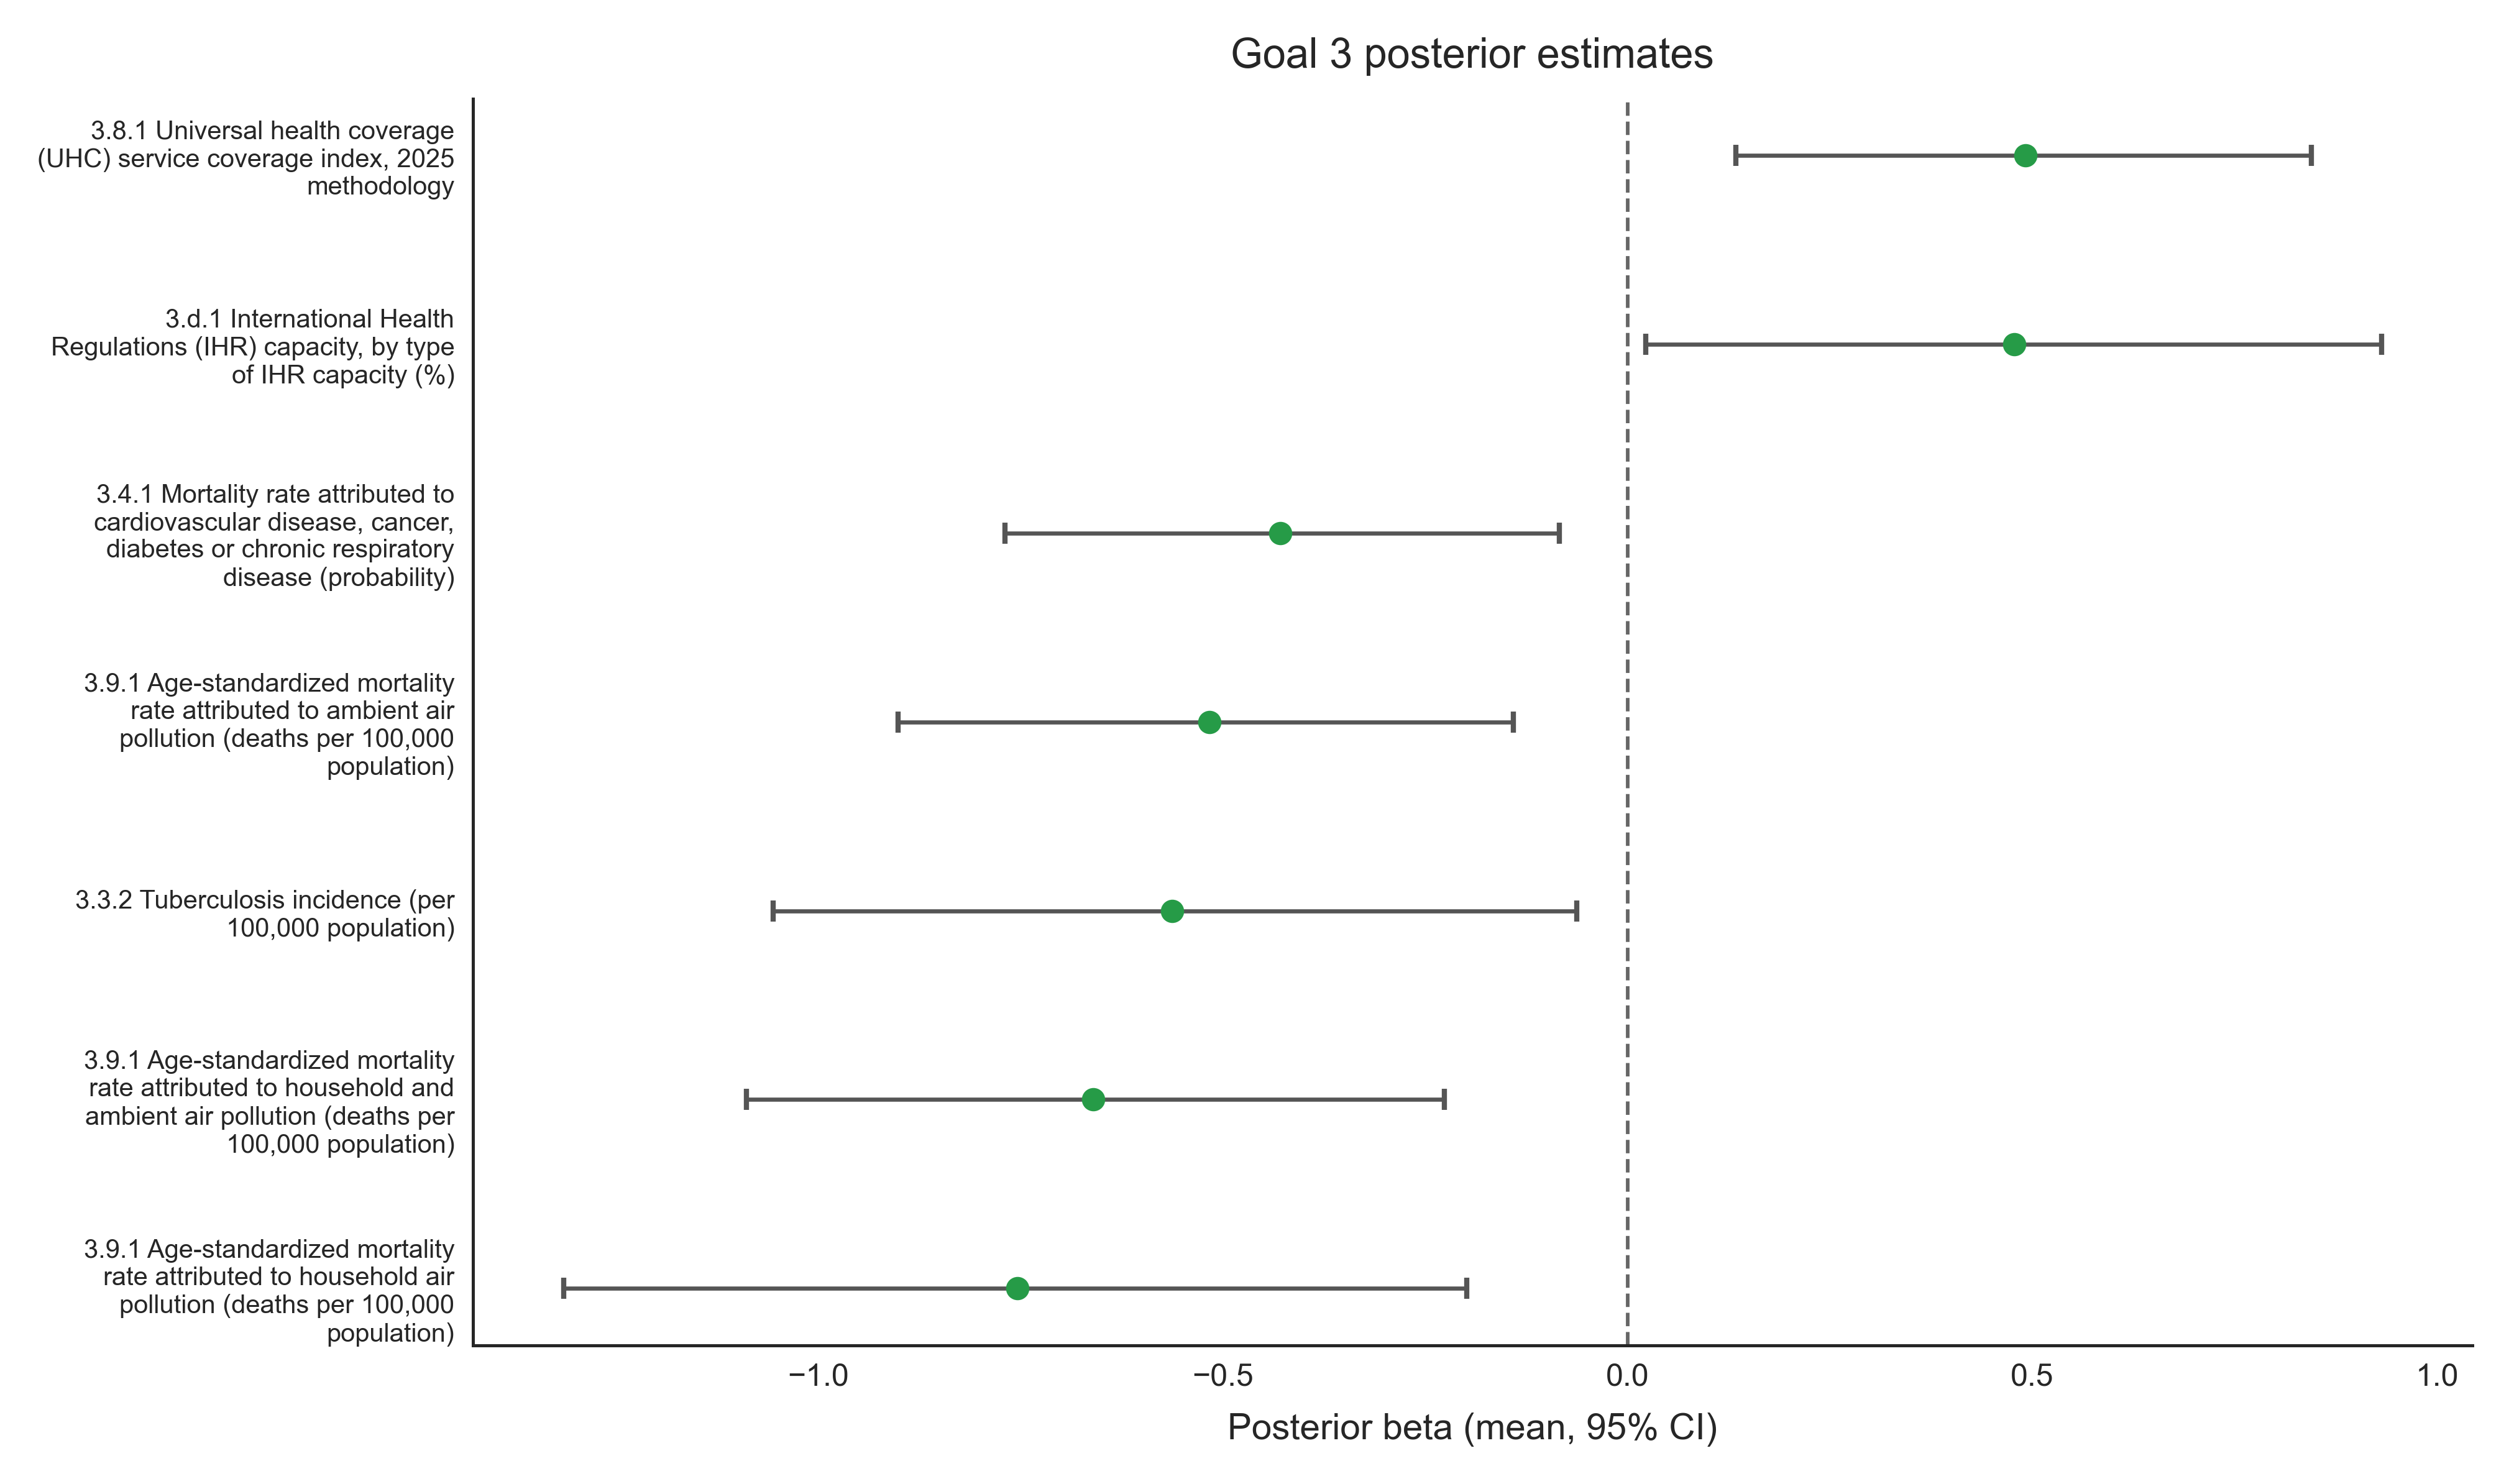

Saved: ../results/f5_reg3var/sdg_goal3_bayes_posterior_estimates.pdf


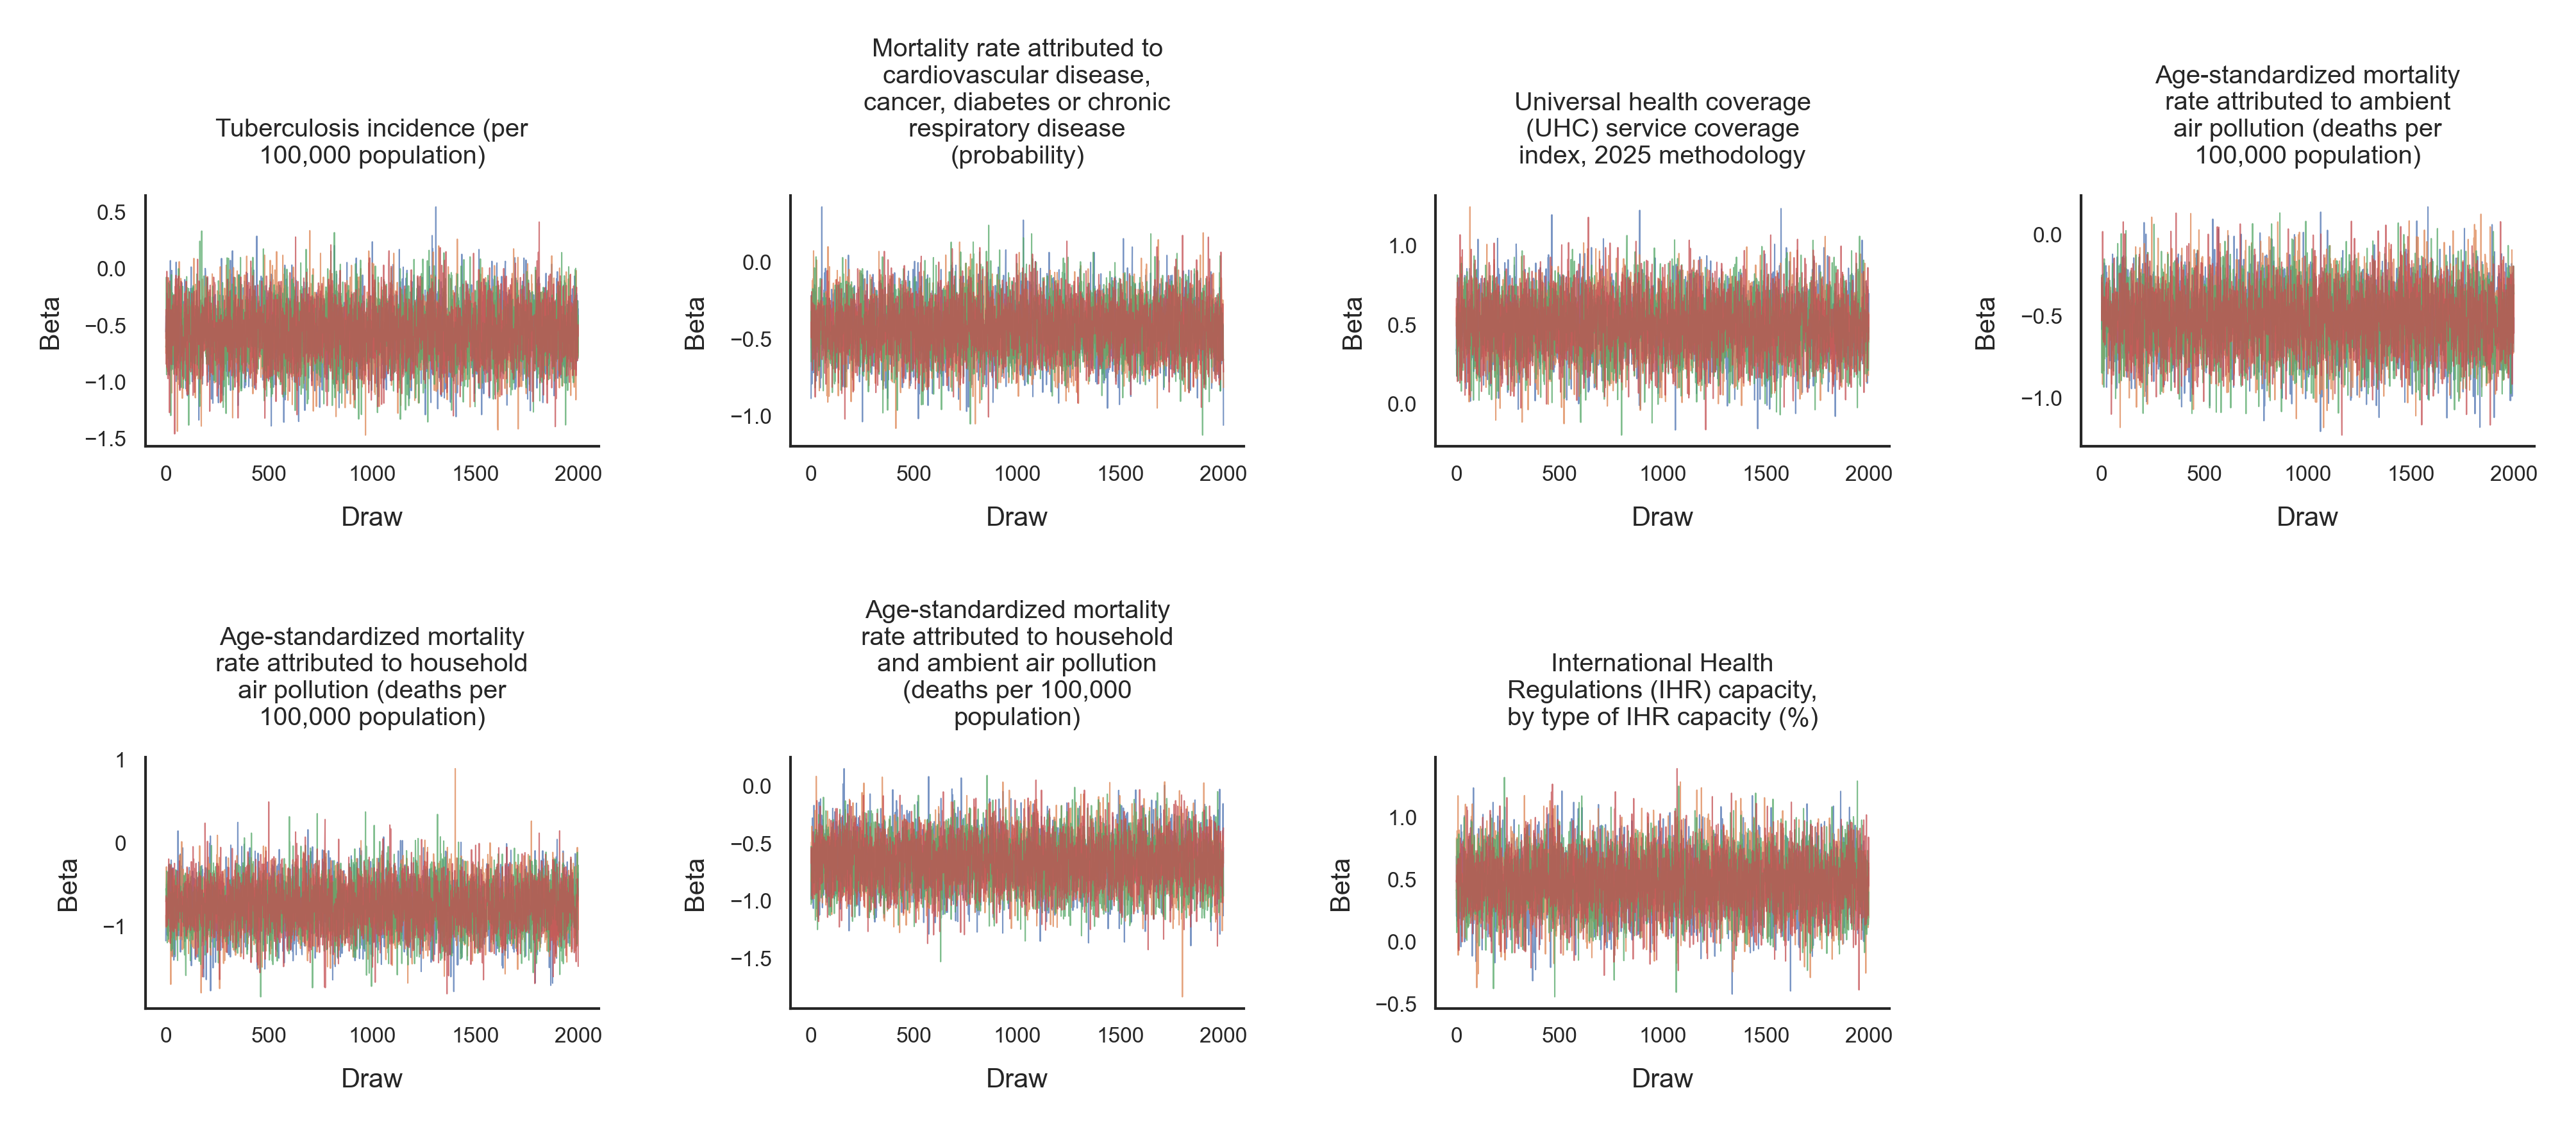

Saved: ../results/f5_reg3var/sdg_goal3_bayes_trace_plots.pdf


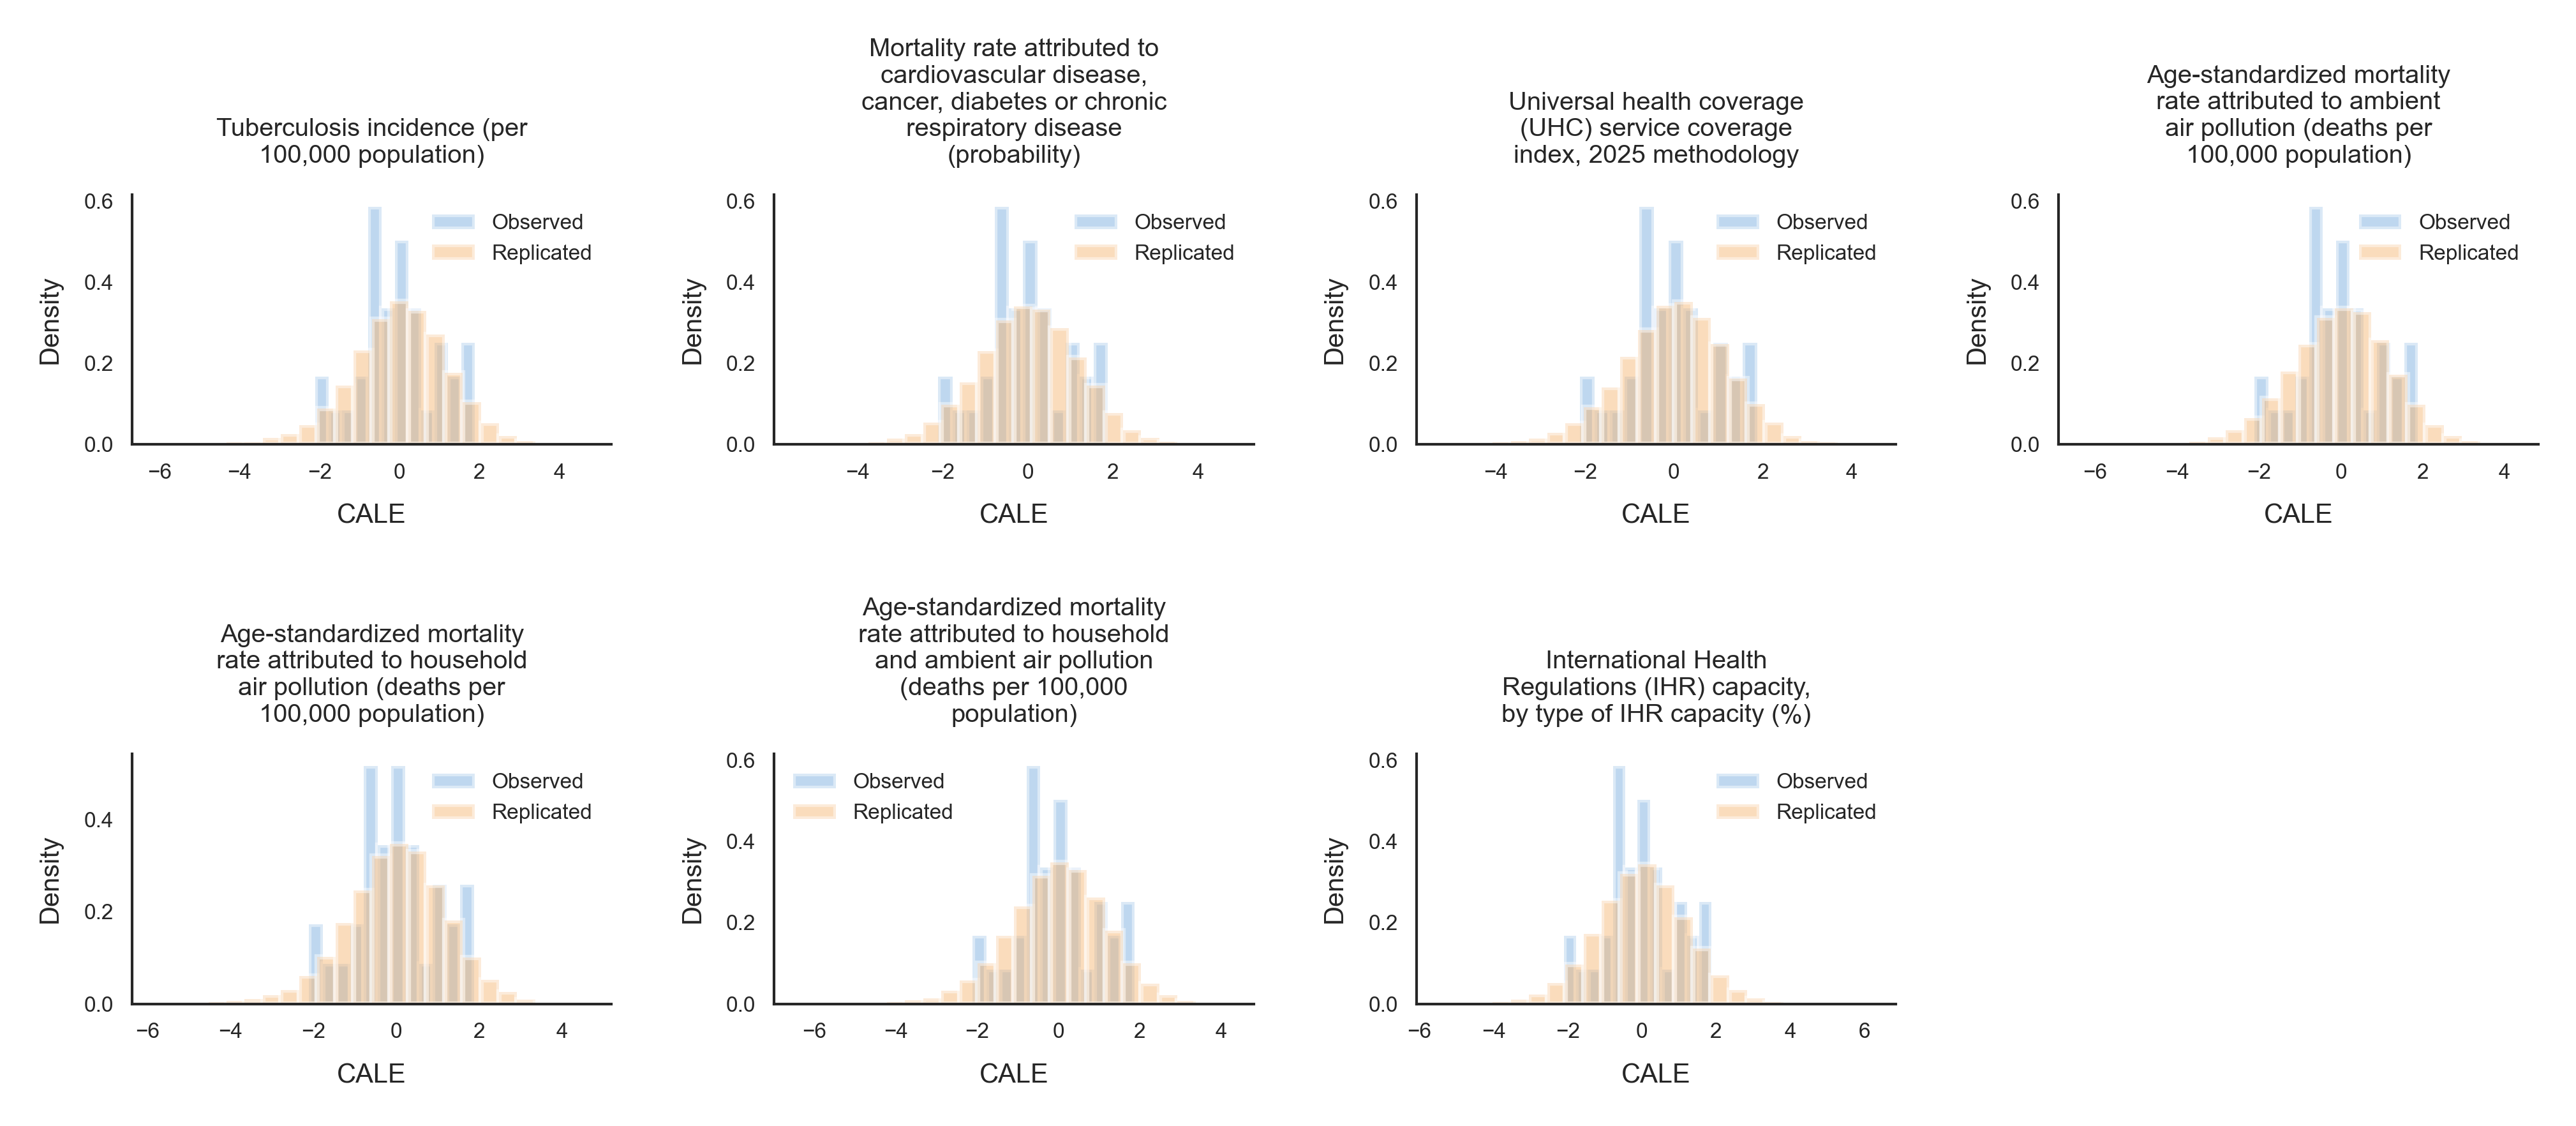

Saved: ../results/f5_reg3var/sdg_goal3_bayes_posterior_predictive_checks.pdf


In [9]:
# (9) Bayesian MCMC diagnostic plots for significant SDG3 indicators
if bayes_summary.empty:
    print("No Bayesian results to plot.")
else:
    plot_df = bayes_summary.copy()
    plot_df["label"] = plot_df["indicator"].astype(str) + " " + plot_df["seriesDescription"].astype(str)
    plot_df = plot_df.sort_values("posterior_mean")

    def wrap_plot_label(text, width=34):
        return "\n".join(textwrap.wrap(str(text), width=width))

    # Posterior interval plot
    fig_h = max(2.8, 0.42 * len(plot_df) + 1.2)
    fig, ax = plt.subplots(figsize=(175 / 25.4, fig_h), dpi=600)
    y_pos = np.arange(len(plot_df))
    ax.errorbar(
        plot_df["posterior_mean"],
        y_pos,
        xerr=[plot_df["posterior_mean"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["posterior_mean"]],
        fmt="o",
        color="#269B47",
        ecolor="#555555",
        elinewidth=0.8,
        capsize=2,
        markersize=3.5,
    )
    ax.axvline(0, color="#666666", linestyle="--", linewidth=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([wrap_plot_label(x, 36) for x in plot_df["label"]], fontsize=5)
    ax.tick_params(axis="x", labelsize=6, length=0)
    ax.tick_params(axis="y", length=0)
    ax.set_xlabel("Posterior beta (mean, 95% CI)", fontsize=7)
    ax.set_title("Goal 3 posterior estimates", fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["bottom"].set_linewidth(0.6)
    fig.tight_layout()
    plt.savefig(BAYES_POSTERIOR_PLOT, dpi=600, bbox_inches="tight", pad_inches=0.03)
    plt.show()
    print("Saved:", BAYES_POSTERIOR_PLOT)

    # Trace plots
    n_vars = len(sig_bayes_vars)
    ncols = 4
    nrows = int(np.ceil(n_vars / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(175 / 25.4, max(2.4, 1.55 * nrows)), dpi=600)
    axes = np.atleast_1d(axes).ravel()
    for ax_idx, ax in enumerate(axes):
        if ax_idx >= n_vars:
            ax.set_visible(False)
            continue
        var = sig_bayes_vars[ax_idx]
        for chain in trace_store[var]:
            ax.plot(chain, linewidth=0.25, alpha=0.75)
        label = sig_bayes.loc[sig_bayes["variable"].eq(var), "seriesDescription"].iloc[0]
        ax.set_title(wrap_plot_label(label, 28), fontsize=4.8)
        ax.set_xlabel("Draw", fontsize=5)
        ax.set_ylabel("Beta", fontsize=5)
        ax.tick_params(axis="both", labelsize=4, length=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.5)
        ax.spines["bottom"].set_linewidth(0.5)
    fig.tight_layout()
    plt.savefig(BAYES_TRACE_PLOT, dpi=600, bbox_inches="tight", pad_inches=0.03)
    plt.show()
    print("Saved:", BAYES_TRACE_PLOT)

    # Posterior predictive checks
    fig, axes = plt.subplots(nrows, ncols, figsize=(175 / 25.4, max(2.4, 1.55 * nrows)), dpi=600)
    axes = np.atleast_1d(axes).ravel()
    for ax_idx, ax in enumerate(axes):
        if ax_idx >= n_vars:
            ax.set_visible(False)
            continue
        var = sig_bayes_vars[ax_idx]
        obs = ppc_store[var]["observed"]
        rep = ppc_store[var]["replicated"]
        ax.hist(obs, bins=12, density=True, alpha=0.45, color="#6FA8DC", label="Observed")
        ax.hist(rep, bins=24, density=True, alpha=0.45, color="#F6B26B", label="Replicated")
        label = sig_bayes.loc[sig_bayes["variable"].eq(var), "seriesDescription"].iloc[0]
        ax.set_title(wrap_plot_label(label, 28), fontsize=4.8)
        ax.set_xlabel("CALE", fontsize=5)
        ax.set_ylabel("Density", fontsize=5)
        ax.tick_params(axis="both", labelsize=4, length=0)
        ax.legend(frameon=False, fontsize=4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.5)
        ax.spines["bottom"].set_linewidth(0.5)
    fig.tight_layout()
    plt.savefig(BAYES_PPC_PLOT, dpi=600, bbox_inches="tight", pad_inches=0.03)
    plt.show()
    print("Saved:", BAYES_PPC_PLOT)

In [10]:
# (10) Export Bayesian MCMC summary as LaTeX table
BAYES_LATEX_PATH = OUT_DIR / "sdg_goal3_bayes_mcmc_summary.tex"


def latex_escape(value):
    text = "" if pd.isna(value) else str(value)
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    return "".join(replacements.get(ch, ch) for ch in text)


def fmt_num(value, digits=3):
    if pd.isna(value) or not np.isfinite(value):
        return ""
    return f"{float(value):.{digits}f}"


if "bayes_summary" in globals() and not bayes_summary.empty:
    bayes_tex_df = bayes_summary.copy()
elif BAYES_SUMMARY_PATH.exists():
    bayes_tex_df = pd.read_csv(BAYES_SUMMARY_PATH)
else:
    raise RuntimeError("Run cell (8) first or create sdg_goal3_bayes_mcmc_summary.csv before exporting LaTeX.")

keep_cols = ["indicator", "seriesDescription", "posterior_mean", "ci_low", "ci_high", "prob_direction"]
missing = [c for c in keep_cols if c not in bayes_tex_df.columns]
if missing:
    raise ValueError(f"Missing columns for Bayesian LaTeX table: {missing}")

bayes_tex_df = bayes_tex_df[keep_cols].copy()
bayes_tex_df["indicator_sort"] = bayes_tex_df["indicator"].map(indicator_sort_key)
bayes_tex_df = bayes_tex_df.sort_values(["indicator_sort", "seriesDescription"]).drop(columns="indicator_sort").reset_index(drop=True)
bayes_tex_df["95% CrI"] = bayes_tex_df.apply(lambda r: f"({fmt_num(r['ci_low'])} , {fmt_num(r['ci_high'])})", axis=1)

header = ["Indicator", "Description", "Posterior mean", r"95\% CrI", "pd"]
latex_lines = [
    r"\begin{table}[htbp]",
    r"\centering",
    r"\small",
    r"\begin{tabular}{lp{7cm}ccc}",
    r"\hline\hline",
    " & ".join(header) + r" \\",
    r"\hline",
]

for _, row in bayes_tex_df.iterrows():
    latex_lines.append(
        " & ".join([
            latex_escape(row["indicator"]),
            latex_escape(row["seriesDescription"]),
            fmt_num(row["posterior_mean"]),
            row["95% CrI"],
            fmt_num(row["prob_direction"]),
        ]) + r" \\"
    )

latex_lines.extend([
    r"\hline\hline",
    r"\end{tabular}",
    r"\caption{Goal 3 Bayesian MCMC posterior summary}",
    r"\end{table}",
    "",
])

BAYES_LATEX_PATH.write_text("\n".join(latex_lines))
display(bayes_tex_df[["indicator", "seriesDescription", "posterior_mean", "95% CrI", "prob_direction"]])
print("Saved:", BAYES_LATEX_PATH)


,indicator,seriesDescription,posterior_mean,95% CrI,prob_direction
0,3.3.2,"Tuberculosis incidence (per 100,000 population)",-0.563039,"(-1.056 , -0.063)",0.984875
1,3.4.1,Mortality rate attributed to cardiovascular di...,-0.429537,"(-0.769 , -0.084)",0.990875
2,3.8.1,Universal health coverage (UHC) service covera...,0.491264,"(0.134 , 0.845)",0.996125
3,3.9.1,Age-standardized mortality rate attributed to ...,-0.516701,"(-0.901 , -0.141)",0.993125
4,3.9.1,Age-standardized mortality rate attributed to ...,-0.753988,"(-1.315 , -0.199)",0.994375
5,3.9.1,Age-standardized mortality rate attributed to ...,-0.660589,"(-1.089 , -0.227)",0.998250
6,3.d.1,International Health Regulations (IHR) capacit...,0.477360,"(0.022 , 0.931)",0.979875


Saved: ../results/f5_reg3var/sdg_goal3_bayes_mcmc_summary.tex
